In [1]:
import numpy as np
import matplotlib.pyplot as plt
cmap = 'tab10'
import pandas as pd


import pickle

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *

import time


# Load Data

In [2]:
path = 'C:/Users/codae/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4'
df= pd.read_csv(path + '//fashion-mnist_train.csv')

In [3]:
fmnist = PCA(n_components = 50).fit_transform(df.iloc[:,1:].to_numpy()/255)
labels = df['label'].to_numpy()

fmnist.shape, labels.shape

((60000, 50), (60000,))

In [4]:
np.unique(labels, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
       dtype=int64))

## Cluster

In [6]:
st = time.time()
adata = sc.AnnData(fmnist)
sc.pp.neighbors(adata, n_neighbors=15)
time.time()-st

45.60309600830078

In [7]:
st = time.time()
sc.tl.leiden(adata, resolution=0.315) #set resolution so that have 10 clusters
clusters = adata.obs['leiden']
print(time.time()-st)
rand_score(clusters, labels)

C:\Users\codae\AppData\Local\Temp\ipykernel_15576\1062988228.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.315) #set resolution so that have 10 clusters


11.020577192306519


0.8989791152074756

In [8]:
clusters = np.array(clusters).astype(int)
confusion_matrix(labels,clusters)

array([[ 254,    2,    2, 4807,  791,    3,   15,   77,   21,   28],
       [  93,    0,    1,   15,  227, 5644,    4,   15,    0,    1],
       [4365,    1,    1,   58,   41,    1, 1381,  122,    8,   22],
       [  98,    0,    0,  173, 4137,   24,   12, 1542,    8,    6],
       [2905,    0,    0,   25,  170,    2, 1683, 1187,   14,   14],
       [   1, 3654, 2319,    8,    2,    0,    0,    0,    3,   13],
       [3239,    0,    1, 1403,  563,    2,  515,  202,    8,   67],
       [   0, 5514,  486,    0,    0,    0,    0,    0,    0,    0],
       [ 338,   35,   12,   15,  137,    0,   19,   28, 2858, 2558],
       [   0,  315, 5684,    0,    0,    0,    0,    0,    0,    1]],
      dtype=int64)

In [9]:
np.unique(clusters, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([11293,  9521,  8506,  6504,  6068,  5676,  3629,  3173,  2920,
         2710], dtype=int64))

## Embed each cluster

In [9]:
st = time.time()
l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
time.time()-st

9.776806116104126

## Align 

In [10]:
st = time.time()
# approximate geodesic distances 
alignment_idxs = np.random.choice(n, 20000, replace = False)
D = shortest_path(
    (adata[alignment_idxs]).obsp["distances"],
    directed=False,
    indices= np.arange(5000) # only compute from these sources
)

alignment_idxs = alignment_idxs[0:5000]
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]
D = D[:,0:5000]
D[np.isinf(D)] =  np.max(D[np.isfinite(D)]) # replace infinite values

#reformat
distances = {} 

n_clusters = 10
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]
time.time()-st

48.264806509017944

In [13]:
st = time.time()
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
ce_1 = out.align_embedding(m = 50 )
ce_1 =  out.embed_points(embeddings,clusters)
time.time()-st

7.1934874057769775

In [14]:
st = time.time()
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.7)
ce_135 = out.align_embedding(m = 50 )
ce_135 =  out.embed_points(embeddings,clusters)
time.time()-st

9.292885303497314

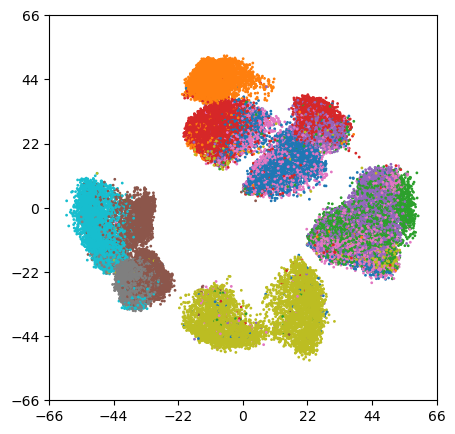

In [8]:
plt.figure(figsize = [5,5])
plt.scatter(ce_135[:,0], ce_135[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-66,66)
plt.ylim(-66,66)
plt.xticks(np.linspace(-66,66,7))
plt.yticks(np.linspace(-66,66,7))
plt.savefig('../figures/fmnist/ce_17.png', format='png', dpi=300, bbox_inches='tight')

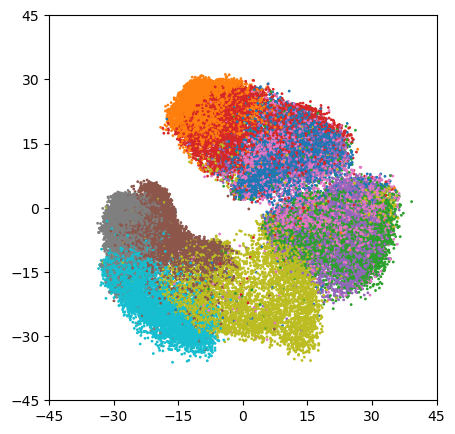

In [9]:
ce_1_, _ = procrustes(ce_135, ce_1)
plt.figure(figsize = [5,5])
plt.scatter(ce_1_[:,0], ce_1_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-45,45)
plt.ylim(-45,45)
plt.xticks(np.linspace(-45,45,7))
plt.yticks(np.linspace(-45,45,7))
plt.savefig('../figures/fmnist/ce_1.png', format='png', dpi=300, bbox_inches='tight')

In [6]:
# #check: look at some random examples from bag clusters..
# for i in range(10):
#     idxs = np.where(clusters == i)[0]
#     sampled = np.random.choice(idxs, size=10, replace=False)

#     fig,axs = plt.subplots(2,5, figsize = [25,10])
#     for j in range(10):
#         axs[j//5, j%5].imshow(df.iloc[sampled[j],1:].to_numpy().reshape(28,28), cmap = 'Greys')
#     plt.show()
#     print()
    

In [43]:
# save embeddings and clusters
with open('../results/fmnist/clusters.pkl', 'wb') as file:  
    pickle.dump(clusters, file)

with open('../results/fmnist/isomap_embeddings.pkl', 'wb') as file:  
    pickle.dump([ce_1, ce_135], file)
with open('../results/fmnist/embedding_data.pkl', 'wb') as file:  
    pickle.dump([alignment_idxs, distances], file)

In [11]:

st = time.time()
trimap_embeddings =  np.load("../results/fmnist/trimap_clusters.npy", allow_pickle=False)

# rescale the embeddings:
for i in range(10):
    scaling_idxs = clusters[alignment_idxs] == i  #T/F on the alignment idxs if in cluster i
    orig_pdist = squareform(D[scaling_idxs,:][:,scaling_idxs])
    emb_pdist = pdist(trimap_embeddings[alignment_idxs[scaling_idxs]])
    scale  = np.sum(orig_pdist*emb_pdist)/np.sum(emb_pdist**2)
    trimap_embeddings[clusters == i] *= scale
time.time()-st

0.15685772895812988

In [13]:
embedding_sampled = trimap_embeddings[alignment_idxs,:]

In [14]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1)
out.get_default_alpha()

1.8705133025983143

In [15]:
st = time.time()
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.87)
ce_trimap = out.align_embedding(m = 50 )
ce_trimap =  out.embed_points(trimap_embeddings,clusters)
time.time()-st

7.0057995319366455

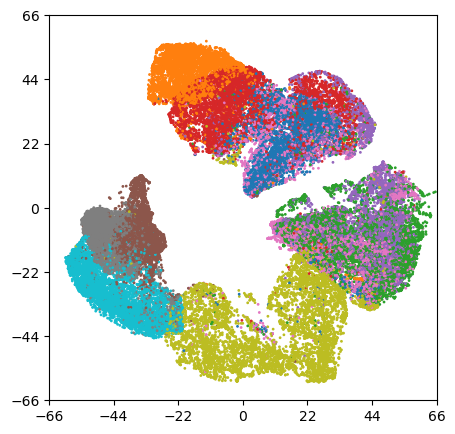

In [20]:
ce_trimap_, _ =procrustes(ce_135, ce_trimap)

plt.figure(figsize = [5,5])
plt.scatter(ce_trimap_[:,0], ce_trimap_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-66,66)
plt.ylim(-66,66)
plt.xticks(np.linspace(-66,66,7))
plt.yticks(np.linspace(-66,66,7))
plt.savefig('../figures/fmnist/ce_trimap.png', format='png', dpi=300, bbox_inches='tight')

In [21]:
with open('../results/fmnist/ce_trimap.pkl', 'wb') as file:  
    pickle.dump(ce_trimap, file)

### Other methods

In [18]:
st = time.time()
tsne30 = TSNE(perplexity = 30, negative_gradient_method="fft").fit(fmnist)
tsne30 = np.array(tsne30)
time.time()-st

248.80512475967407

In [19]:
st = time.time()
pca = PCA(n_components = 2).fit_transform(fmnist)
time.time()-st

0.023029565811157227

In [20]:
st = time.time()
l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 1000)
isomap =  l_isomap.fit_transform(adata)
time.time()-st

55.85341954231262

In [6]:
st = time.time()
umap = UMAP().fit_transform(fmnist)
time.time()-st

38.814552783966064

In [22]:
st = time.time()
phate = PHATE().fit_transform(fmnist)
time.time()-st

Calculating PHATE...
  Running PHATE on 60000 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 6.56 seconds.
    Calculating affinities...


C:\Users\codae\anaconda3\Lib\site-packages\graphtools\graphs.py:810: RuntimeWarning: Detected zero distance between 27 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 2.88 seconds.
  Calculated graph and diffusion operator in 9.50 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 6.94 seconds.
    Calculating KMeans...
    Calculated KMeans in 8.90 seconds.
  Calculated landmark operator in 15.84 seconds.
  Calculating optimal t...
    Automatically selected t = 29
  Calculated optimal t in 2.43 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.86 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.16 seconds.
Calculated PHATE in 35.47 seconds.


35.47161650657654

In [55]:
trimap =  np.load("../results/fmnist/trimap_full.npy", allow_pickle=False)

In [7]:
tsne30_, _  = procrustes(ce_135, tsne30)
pca_, _  = procrustes(ce_135, pca)
isomap_, _  = procrustes(ce_135, isomap)
umap_, _  = procrustes(ce_135, umap)
phate_, _  = procrustes(ce_135, phate)
trimap_, _  = procrustes(ce_135, trimap)

In [27]:
all_embs = [ce_1, ce_135, ce_trimap, tsne30, pca, isomap, umap, phate, trimap]
results = [all_embs, labels, clusters]

with open('../results/fmnist/embeddings.pkl', 'wb') as file:  
    pickle.dump(results, file)

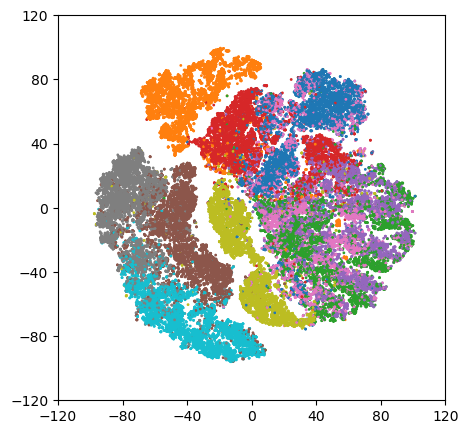

In [12]:
plt.figure(figsize = [5,5])
plt.scatter(tsne30_[:,0], tsne30_[:,1], c = labels, s = 1, cmap = cmap)
plt.xlim(-120,120)
plt.ylim(-120,120)
plt.xticks(np.linspace(-120,120,7))
plt.yticks(np.linspace(-120,120,7))
plt.savefig('../figures/fmnist/tsne.png', format='png', dpi=300, bbox_inches='tight')

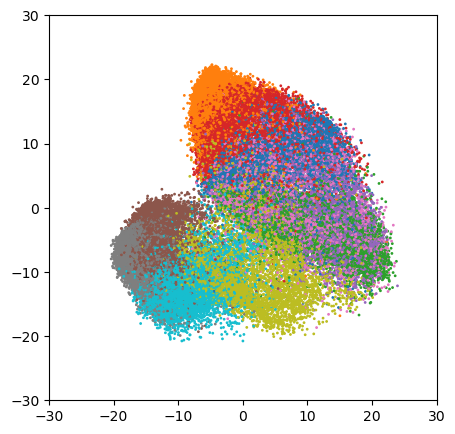

In [13]:
plt.figure(figsize = [5,5])
plt.scatter(isomap_[:,0], isomap_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-30,30)
plt.ylim(-30,30)
plt.xticks(np.linspace(-30,30,7))
plt.yticks(np.linspace(-30,30,7))
plt.savefig('../figures/fmnist/isomap.png', format='png', dpi=300, bbox_inches='tight')

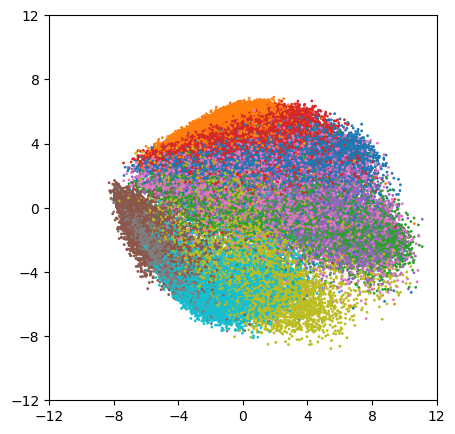

In [14]:
plt.figure(figsize = [5,5])
plt.scatter(pca_[:,0], pca_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(np.linspace(-12,12,7))
plt.yticks(np.linspace(-12,12,7))
plt.savefig('../figures/fmnist/pca.png', format='png', dpi=300, bbox_inches='tight')

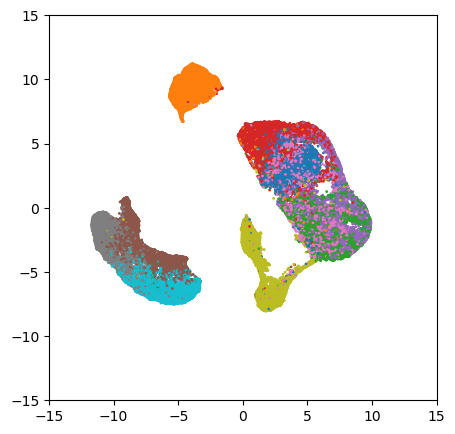

In [15]:
plt.figure(figsize = [5,5])
plt.scatter(umap_[:,0], umap_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.xticks(np.linspace(-15,15,7))
plt.yticks(np.linspace(-15,15,7))
plt.savefig('../figures/fmnist/umap.png', format='png', dpi=300, bbox_inches='tight')

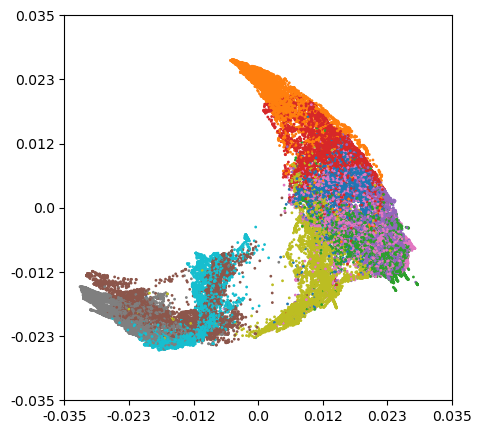

In [10]:
plt.figure(figsize = [5,5])
plt.scatter(phate_[:,0], phate_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-.04,.03)
plt.ylim(-.03,.04)
plt.xticks(np.linspace(-.04,.03,7), np.round(np.linspace(-.035,.035,7),3))
plt.yticks(np.linspace(-.03,.04,7), np.round(np.linspace(-.035,.035,7),3))
plt.savefig('../figures/fmnist/phate.png', format='png', dpi=300, bbox_inches='tight')

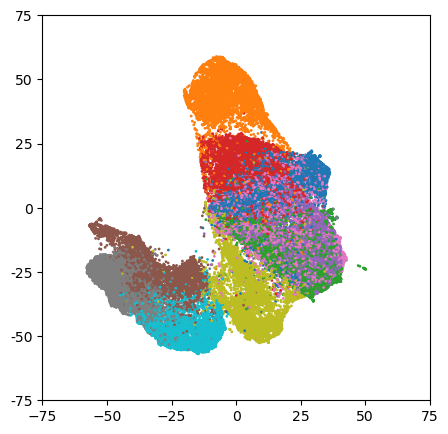

In [11]:
plt.figure(figsize = [5,5])
plt.scatter(trimap_[:,0], trimap_[:,1], c = labels, cmap = cmap, s = 1)
plt.ylim(-60,80)
plt.xlim(-75,75)
plt.yticks(np.linspace(-60,80,7), np.linspace(-75,75,7).astype(int))
plt.xticks(np.linspace(-75,75,7))
plt.savefig('../figures/fmnist/trimap.png', format='png', dpi=300, bbox_inches='tight')

# Evaluation

In [16]:

with open('../results/fmnist/embeddings.pkl', 'rb') as file:  
    results = pickle.load( file)
all_embs = results[0]
ce_1, ce_135, ce_trimap, tsne30, pca, isomap, umap, phate, trimap = all_embs

In [22]:
%%time
idxs = np.random.choice(n, 5000, replace = False)
eval_graph = sc.AnnData(fmnist[idxs])
sc.pp.neighbors(eval_graph, n_neighbors=5)

D = shortest_path(
    eval_graph.obsp["distances"],
    directed=False,
)

CPU times: total: 8.81 s
Wall time: 9.02 s


In [23]:
D = 1/2*(D + D.T)

In [26]:
all_embs = [ce_1, ce_135, ce_trimap, tsne30, pca, isomap, umap, phate, trimap]

In [24]:
orig_distances = D
for emb in all_embs:
    emb_distances =  squareform(pdist(emb[idxs]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[idxs])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[idxs])
    class_score = class_preservation(orig_distances, emb_distances, labels[idxs])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[idxs])
    recall_score = knn_recall(fmnist[idxs], emb[idxs], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()
    
    

$0.79$ & $0.42$ & $0.31$ & $0.30$ & $0.73$ & $0.85$ & $0.24$ & $0.24$ & $0.20$ & $0.24$ & $0.88$

$0.75$ & $0.47$ & $0.41$ & $0.39$ & $0.65$ & $0.80$ & $0.62$ & $0.67$ & $0.22$ & $0.27$ & $0.91$

$0.75$ & $0.52$ & $0.39$ & $0.43$ & $0.64$ & $0.80$ & $0.27$ & $0.27$ & $0.22$ & $0.27$ & $0.89$

$0.77$ & $1.34$ & $0.33$ & $0.46$ & $0.57$ & $0.74$ & $1.62$ & $1.67$ & $0.25$ & $0.29$ & $0.80$

$0.63$ & $0.81$ & $0.40$ & $0.18$ & $0.63$ & $0.74$ & $0.79$ & $0.79$ & $0.27$ & $0.30$ & $0.84$

$0.72$ & $0.59$ & $0.34$ & $0.21$ & $0.74$ & $0.84$ & $0.47$ & $0.47$ & $0.21$ & $0.25$ & $0.84$

$0.80$ & $0.85$ & $0.37$ & $0.43$ & $0.56$ & $0.75$ & $0.72$ & $0.72$ & $0.22$ & $0.31$ & $0.83$

$0.71$ & $1.00$ & $0.38$ & $0.27$ & $0.55$ & $0.74$ & $1.00$ & $1.00$ & $0.25$ & $0.36$ & $0.80$

$0.76$ & $0.37$ & $0.33$ & $0.36$ & $0.63$ & $0.77$ & $0.45$ & $0.51$ & $0.22$ & $0.30$ & $0.80$



In [28]:
recall_results = []

for emb in all_embs:
    recall_score = knn_recall(fmnist[idxs,:], emb[idxs,:], np.arange(5,250,5))
    recall_results += [recall_score]

In [29]:
colors = ['#3182bd', '#aec7e8', '#17becf', '#ff7f0e', '#d62728', '#31a354', '#8c564b','#9467bd',  '#e377c2']

In [37]:
plt.rcParams.update({'font.size': 10})

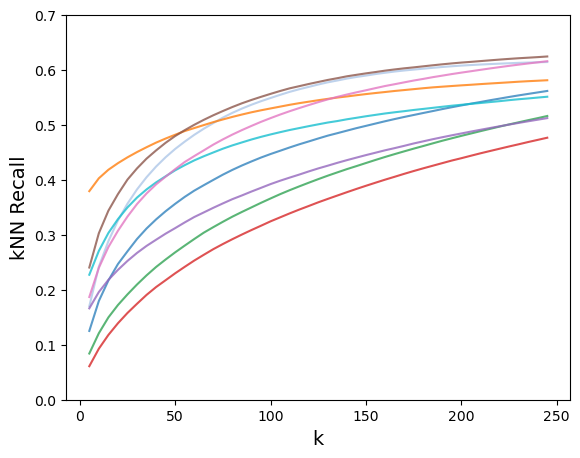

In [39]:
plt.figure(figsize = [6.5,5])
recall_labels  = [r'C+E ($\alpha = 1$)', r'C+E ($\alpha = 1.25$)', 'C+E trimap', 't-SNE (u = 30)',
          'PCA', 'L-Isomap', 'UMAP', 'PHATE', 'TriMap']
for i,r in enumerate(recall_results):
    plt.plot(np.arange(5,250,5), r, label = recall_labels[i], color = colors[i], alpha = .8)
# plt.legend()
plt.xlabel('k', fontsize = 14)
plt.ylabel('kNN Recall', fontsize = 14)
plt.ylim(0,.7)
plt.savefig('../figures/fmnist/knn.png', format='png', dpi=300, bbox_inches='tight')